In [23]:
# Cell 1: Setup and Data Preparation
# =========================================
# 🧩 Deepfake Detection with EfficientNet, SE, and Attention Modules
# Dataset: WildDeepfake (KaggleHub)
# =========================================

# Install required packages first
import subprocess
import sys

def install_package(package):
    """Install a package using pip"""
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✅ Successfully installed {package}")
    except subprocess.CalledProcessError:
        print(f"❌ Failed to install {package}")

# Install kagglehub if not available
try:
    import kagglehub
    print("✅ kagglehub already installed")
except ImportError:
    print("📦 Installing kagglehub...")
    install_package("kagglehub")
    import kagglehub

# Standard imports
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout, Multiply,
                                   Reshape, Conv2D, Add, Lambda, Concatenate, GlobalMaxPooling2D,
                                   BatchNormalization, Activation, Input)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful!")

# Set memory growth for GPU if available
if tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True)
        print("🎮 GPU memory growth enabled")
    except:
        print("💻 GPU available but memory growth not set")
else:
    print("💻 Running on CPU")

✅ kagglehub already installed
✅ All imports successful!
🎮 GPU memory growth enabled


In [24]:
# Cell 2: Dataset Download and Setup
# =========================================
# 1️⃣ Download and Setup Dataset
# =========================================

def download_and_setup_dataset():
    """Download and setup the WildDeepfake dataset with proper error handling"""
    try:
        print("⬇️ Downloading WildDeepfake dataset...")
        download_path = kagglehub.dataset_download("maysuni/wild-deepfake")
        print(f"✅ Dataset downloaded at: {download_path}")

        # Unzip if necessary
        dataset_path = download_path
        for file in os.listdir(download_path):
            if file.endswith(".zip"):
                zip_path = os.path.join(download_path, file)
                extract_dir = os.path.join(download_path, "WildDeepfake")
                if not os.path.exists(extract_dir):
                    print("📦 Extracting dataset...")
                    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                        zip_ref.extractall(extract_dir)
                    print("✅ Dataset extracted successfully")
                dataset_path = extract_dir
                break

        # Verify the path and find the correct directory containing 'fake' and 'real' folders
        if not os.path.exists(os.path.join(dataset_path, "fake")) or not os.path.exists(os.path.join(dataset_path, "real")):
            print("🔍 Searching for 'fake' and 'real' directories...")
            found_path = None
            for root, dirs, files in os.walk(download_path):
                if 'fake' in dirs and 'real' in dirs:
                    found_path = root
                    break
            if found_path:
                dataset_path = found_path
                print(f"✅ Found directories at: {dataset_path}")
            else:
                raise FileNotFoundError("❌ Could not find 'fake' and 'real' directories in dataset.")

        print(f"📁 Using dataset path: {dataset_path}")

        # Verify dataset contents
        fake_dir = os.path.join(dataset_path, "fake")
        real_dir = os.path.join(dataset_path, "real")

        if os.path.exists(fake_dir) and os.path.exists(real_dir):
            fake_count = len([f for f in os.listdir(fake_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            real_count = len([f for f in os.listdir(real_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"📊 Dataset verification:")
            print(f"   - Fake images: {fake_count}")
            print(f"   - Real images: {real_count}")
            print(f"   - Total images: {fake_count + real_count}")

        return dataset_path

    except Exception as e:
        print(f"❌ Error downloading dataset: {str(e)}")
        print("💡 Please manually download the dataset and update the path below")
        # Return a placeholder path - user should update this
        return r"C:\path\to\your\dataset"

# Download and setup dataset
dataset_path = download_and_setup_dataset()

⬇️ Downloading WildDeepfake dataset...
Using Colab cache for faster access to the 'wild-deepfake' dataset.
✅ Dataset downloaded at: /kaggle/input/wild-deepfake
🔍 Searching for 'fake' and 'real' directories...
✅ Found directories at: /kaggle/input/wild-deepfake/valid
📁 Using dataset path: /kaggle/input/wild-deepfake/valid
📊 Dataset verification:
   - Fake images: 9180
   - Real images: 8168
   - Total images: 17348


In [25]:
# Cell 3: Data Generators Setup
# =========================================
# 2️⃣ Data Preprocessing and Augmentation
# =========================================

def setup_data_generators(dataset_path):
    """Setup data generators with error handling"""
    try:
        img_size = (224, 224)
        batch_size = 32

        # Enhanced data augmentation for training
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            shear_range=0.15,
            zoom_range=0.15,
            brightness_range=[0.8, 1.2],
            horizontal_flip=True,
            fill_mode='nearest',
            validation_split=0.2
        )

        # Simple rescaling for validation
        val_datagen = ImageDataGenerator(
            rescale=1./255,
            validation_split=0.2
        )

        # Create training generator
        train_gen = train_datagen.flow_from_directory(
            dataset_path,
            target_size=img_size,
            batch_size=batch_size,
            class_mode='binary',
            subset='training',
            shuffle=True,
            seed=42
        )

        # Create validation generator
        val_gen = val_datagen.flow_from_directory(
            dataset_path,
            target_size=img_size,
            batch_size=batch_size,
            class_mode='binary',
            subset='validation',
            shuffle=False,
            seed=42
        )

        print(f"✅ Data generators created successfully:")
        print(f"   - Training samples: {train_gen.samples}")
        print(f"   - Validation samples: {val_gen.samples}")
        print(f"   - Class indices: {train_gen.class_indices}")

        return train_gen, val_gen, img_size, batch_size

    except Exception as e:
        print(f"❌ Error setting up data generators: {str(e)}")
        print("💡 Please check if the dataset path is correct and contains 'fake' and 'real' folders")
        return None, None, None, None

# Setup data generators
train_gen, val_gen, img_size, batch_size = setup_data_generators(dataset_path)

if train_gen is None or val_gen is None:
    print("❌ Failed to create data generators. Please check your dataset path.")
else:
    print("✅ Data preprocessing setup complete!")

Found 13879 images belonging to 2 classes.
Found 3469 images belonging to 2 classes.
✅ Data generators created successfully:
   - Training samples: 13879
   - Validation samples: 3469
   - Class indices: {'fake': 0, 'real': 1}
✅ Data preprocessing setup complete!


In [26]:
# Cell 4: Custom Modules Definition
# =========================================
# 3️⃣ Custom Module Definitions
# =========================================

def se_block(input_feature, ratio=8):
    """Squeeze-and-Excitation block"""
    channel = input_feature.shape[-1]

    # Squeeze
    se_feature = GlobalAveragePooling2D()(input_feature)
    se_feature = Reshape((1, 1, channel))(se_feature)

    # Excitation
    se_feature = Dense(channel // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se_feature)
    se_feature = Dense(channel, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se_feature)

    # Scale
    feature = Multiply()([input_feature, se_feature])
    return feature

def cbam_block(input_feature, ratio=8):
    """Convolutional Block Attention Module (CBAM)"""

    # Channel Attention
    channel = input_feature.shape[-1]

    # Average and Max pooling for channel attention
    avg_pool = GlobalAveragePooling2D(keepdims=True)(input_feature)
    max_pool = GlobalMaxPooling2D(keepdims=True)(input_feature)

    # Shared MLP for channel attention
    avg_pool = Dense(channel // ratio, activation='relu')(avg_pool)
    avg_pool = Dense(channel, activation='sigmoid')(avg_pool)

    max_pool = Dense(channel // ratio, activation='relu')(max_pool)
    max_pool = Dense(channel, activation='sigmoid')(max_pool)

    # Channel attention
    channel_attention = Add()([avg_pool, max_pool])
    feature = Multiply()([input_feature, channel_attention])

    # Spatial Attention
    avg_pool = Lambda(lambda x: tf.keras.backend.mean(x, axis=3, keepdims=True))(feature)
    max_pool = Lambda(lambda x: tf.keras.backend.max(x, axis=3, keepdims=True))(feature)

    spatial_attention = Concatenate(axis=3)([avg_pool, max_pool])
    spatial_attention = Conv2D(1, (7, 7), strides=1, padding='same', activation='sigmoid',
                              kernel_initializer='he_normal', use_bias=False)(spatial_attention)

    # Apply spatial attention
    feature = Multiply()([feature, spatial_attention])

    return feature

def self_attention_block(input_feature):
    """Self-Attention block"""
    batch_size, height, width, channels = input_feature.shape

    # Query, Key, Value projections
    query = Conv2D(channels // 8, 1, padding='same')(input_feature)
    key = Conv2D(channels // 8, 1, padding='same')(input_feature)
    value = Conv2D(channels, 1, padding='same')(input_feature)

    # Reshape for matrix multiplication
    query = Reshape((height * width, channels // 8))(query)
    key = Reshape((height * width, channels // 8))(key)
    value = Reshape((height * width, channels))(value)

    # Attention weights
    attention = Lambda(lambda x: tf.nn.softmax(tf.matmul(x[0], x[1], transpose_b=True) /
                                              tf.sqrt(float(channels // 8))))([query, key])

    # Apply attention
    attended = Lambda(lambda x: tf.matmul(x[0], x[1]))([attention, value])
    attended = Reshape((height, width, channels))(attended)

    # Add residual connection
    output = Add()([input_feature, attended])
    return output

print("✅ Custom modules defined successfully!")

✅ Custom modules defined successfully!


In [27]:
# Cell 5: Model Architectures
# =========================================
# 4️⃣ Model Architecture Definitions
# =========================================

def create_base_efficientnet(input_shape=(224, 224, 3)):
    """Create base EfficientNet model"""
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    # Freeze base model layers for transfer learning
    base_model.trainable = False
    return base_model

def create_model_1_eff_se_att(input_shape=(224, 224, 3)):
    """Model 1: EfficientNet -> SE -> Attention -> Classifier"""
    print("🏗️ Building Model 1: EfficientNet -> SE -> Attention -> Classifier")

    inputs = Input(shape=input_shape)
    base_model = create_base_efficientnet(input_shape)

    # EfficientNet backbone
    x = base_model(inputs)

    # SE block
    x = se_block(x, ratio=8)

    # CBAM Attention block
    x = cbam_block(x, ratio=8)

    # Classifier
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='EfficientNet_SE_Attention')
    return model

def create_model_2_eff_att_se(input_shape=(224, 224, 3)):
    """Model 2: EfficientNet -> Attention -> SE -> Classifier"""
    print("🏗️ Building Model 2: EfficientNet -> Attention -> SE -> Classifier")

    inputs = Input(shape=input_shape)
    base_model = create_base_efficientnet(input_shape)

    # EfficientNet backbone
    x = base_model(inputs)

    # CBAM Attention block first
    x = cbam_block(x, ratio=8)

    # SE block
    x = se_block(x, ratio=8)

    # Classifier
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='EfficientNet_Attention_SE')
    return model

def create_model_3_se_eff_att(input_shape=(224, 224, 3)):
    """Model 3: SE -> EfficientNet -> Attention -> Classifier"""
    print("🏗️ Building Model 3: SE -> EfficientNet -> Attention -> Classifier")

    inputs = Input(shape=input_shape)

    # Initial conv layer for SE application
    x = Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = se_block(x, ratio=8)

    # Adjust for EfficientNet input
    x = tf.keras.layers.Lambda(lambda x: tf.image.resize(x, [224, 224]))(x)
    x = Conv2D(3, 1, padding='same')(x)  # Adjust channels to match EfficientNet input

    # EfficientNet backbone
    base_model = create_base_efficientnet(input_shape)
    x = base_model(x)

    # CBAM Attention block
    x = cbam_block(x, ratio=8)

    # Classifier
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='SE_EfficientNet_Attention')
    return model

def create_model_4_att_eff_se(input_shape=(224, 224, 3)):
    """Model 4: Attention -> EfficientNet -> SE -> Classifier"""
    print("🏗️ Building Model 4: Attention -> EfficientNet -> SE -> Classifier")

    inputs = Input(shape=input_shape)

    # Initial conv layer for attention application
    x = Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = cbam_block(x, ratio=8)

    # Adjust for EfficientNet input
    x = tf.keras.layers.Lambda(lambda x: tf.image.resize(x, [224, 224]))(x)
    x = Conv2D(3, 1, padding='same')(x)

    # EfficientNet backbone
    base_model = create_base_efficientnet(input_shape)
    x = base_model(x)

    # SE block
    x = se_block(x, ratio=8)

    # Classifier
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='Attention_EfficientNet_SE')
    return model

def create_model_5_se_att_eff(input_shape=(224, 224, 3)):
    """Model 5: SE -> Attention -> EfficientNet -> Classifier"""
    print("🏗️ Building Model 5: SE -> Attention -> EfficientNet -> Classifier")

    inputs = Input(shape=input_shape)

    # Initial processing with SE and Attention
    x = Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = se_block(x, ratio=8)
    x = cbam_block(x, ratio=8)

    # Adjust for EfficientNet input
    x = tf.keras.layers.Lambda(lambda x: tf.image.resize(x, [224, 224]))(x)
    x = Conv2D(3, 1, padding='same')(x)

    # EfficientNet backbone
    base_model = create_base_efficientnet(input_shape)
    x = base_model(x)

    # Classifier
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='SE_Attention_EfficientNet')
    return model

def create_model_6_att_se_eff(input_shape=(224, 224, 3)):
    """Model 6: Attention -> SE -> EfficientNet -> Classifier"""
    print("🏗️ Building Model 6: Attention -> SE -> EfficientNet -> Classifier")

    inputs = Input(shape=input_shape)

    # Initial processing with Attention and SE
    x = Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = cbam_block(x, ratio=8)
    x = se_block(x, ratio=8)

    # Adjust for EfficientNet input
    x = tf.keras.layers.Lambda(lambda x: tf.image.resize(x, [224, 224]))(x)
    x = Conv2D(3, 1, padding='same')(x)

    # EfficientNet backbone
    base_model = create_base_efficientnet(input_shape)
    x = base_model(x)

    # Classifier
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='Attention_SE_EfficientNet')
    return model

print("✅ All model architectures defined successfully!")

✅ All model architectures defined successfully!


In [28]:
# Cell 6: Training Utilities (FIXED)
# =========================================
# 5️⃣ Training and Evaluation Utilities (FIXED ModelCheckpoint Issue)
# =========================================

def compile_and_train_model(model, train_gen, val_gen, model_name, epochs=20):
    """Compile and train a model with callbacks"""
    print(f"🎯 Training {model_name}...")

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )

    # Callbacks - FIXED: Corrected filepath for save_weights_only=True
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7
        ),
        ModelCheckpoint(
            f'{model_name}_best.weights.h5',  # FIXED: Added .weights.h5 extension
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=True
        )
    ]

    # Train model
    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1
    )

    return history

def evaluate_model(model, val_gen, model_name):
    """Evaluate model and return metrics"""
    print(f"📊 Evaluating {model_name}...")

    # Get predictions
    val_gen.reset()
    predictions = model.predict(val_gen, verbose=1)
    y_pred = (predictions > 0.5).astype(int).flatten()
    y_true = val_gen.classes

    # Calculate metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # ROC AUC
    fpr, tpr, _ = roc_curve(y_true, predictions)
    roc_auc = auc(fpr, tpr)

    # Precision-Recall AUC
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, predictions)
    pr_auc = auc(recall_curve, precision_curve)

    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'fpr': fpr,
        'tpr': tpr,
        'precision_curve': precision_curve,
        'recall_curve': recall_curve,
        'predictions': predictions.flatten(),
        'y_true': y_true
    }

    print(f"✅ {model_name} Evaluation Results:")
    print(f"   - Accuracy: {accuracy:.4f}")
    print(f"   - Precision: {precision:.4f}")
    print(f"   - Recall: {recall:.4f}")
    print(f"   - F1-Score: {f1:.4f}")
    print(f"   - ROC AUC: {roc_auc:.4f}")
    print(f"   - PR AUC: {pr_auc:.4f}")

    return metrics

def plot_training_history(history, model_name):
    """Plot training history"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Plot training & validation accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0, 0].set_title(f'{model_name} - Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Plot training & validation loss
    axes[0, 1].plot(history.history['loss'], label='Training Loss')
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 1].set_title(f'{model_name} - Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Plot precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 0].set_title(f'{model_name} - Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Plot recall
    axes[1, 1].plot(history.history['recall'], label='Training Recall')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
    axes[1, 1].set_title(f'{model_name} - Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

print("✅ Training utilities defined successfully! (ModelCheckpoint issue FIXED)")

✅ Training utilities defined successfully! (ModelCheckpoint issue FIXED)


🏗️ Building Model 1: EfficientNet -> SE -> Attention -> Classifier
📋 Model 1 Summary:


Model: "EfficientNet_SE_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_2[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1, 1, 160) │    204,800 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1, 1,      │    204,800 │ dense_8[0][0]     │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 7, 7,      │          0 │ efficientnetb0[0… │
│ (Multiply)          │ 1280)             │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1, 1,      │          0 │ multiply_3[0][0]  │
│ (GlobalAveragePool… │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1, 1,      │          0 │ multiply_3[0][0]  │
│ (GlobalMaxPooling2… │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1, 1, 160) │    204,960 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1, 1, 160) │    204,960 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1, 1,      │    206,080 │ dense_10[0][0]    │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1, 1,      │    206,080 │ dense_12[0][0]    │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 1,      │          0 │ dense_11[0][0],   │
│                     │ 1280)             │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 7, 7,      │          0 │ multiply_3[0][0], │
│ (Multiply)          │ 1280)             │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 7, 7, 2)   │          0 │ lambda_2[0][0],   │
│ (Concatenate)       │                   │            │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,939,782 (22.66 MB)

 Trainable params: 1,889,187 (7.21 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

🎯 Training Model_1_EfficientNet_SE_Attention...
Epoch 1/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 363s 762ms/step - accuracy: 0.5050 - loss: 0.7974 - precision: 0.4648 - recall: 0.3333 - val_accuracy: 0.5293 - val_loss: 0.6917 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 213s 489ms/step - accuracy: 0.5347 - loss: 0.6917 - precision: 0.5338 - recall: 0.0272 - val_accuracy: 0.5293 - val_loss: 0.6920 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 211s 486ms/step - accuracy: 0.5328 - loss: 0.6917 - precision: 0.2870 - recall: 0.0014 - val_accuracy: 0.5293 - val_loss: 0.6914 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 211s 487ms/step - accuracy: 0.5310 - loss: 0.6917 - precision: 0.1712 - recall: 0.0059 - val_accuracy: 0.5293 - val_loss: 0.6916 - val_precision: 0.0000e+00 - val_recall: 0.0

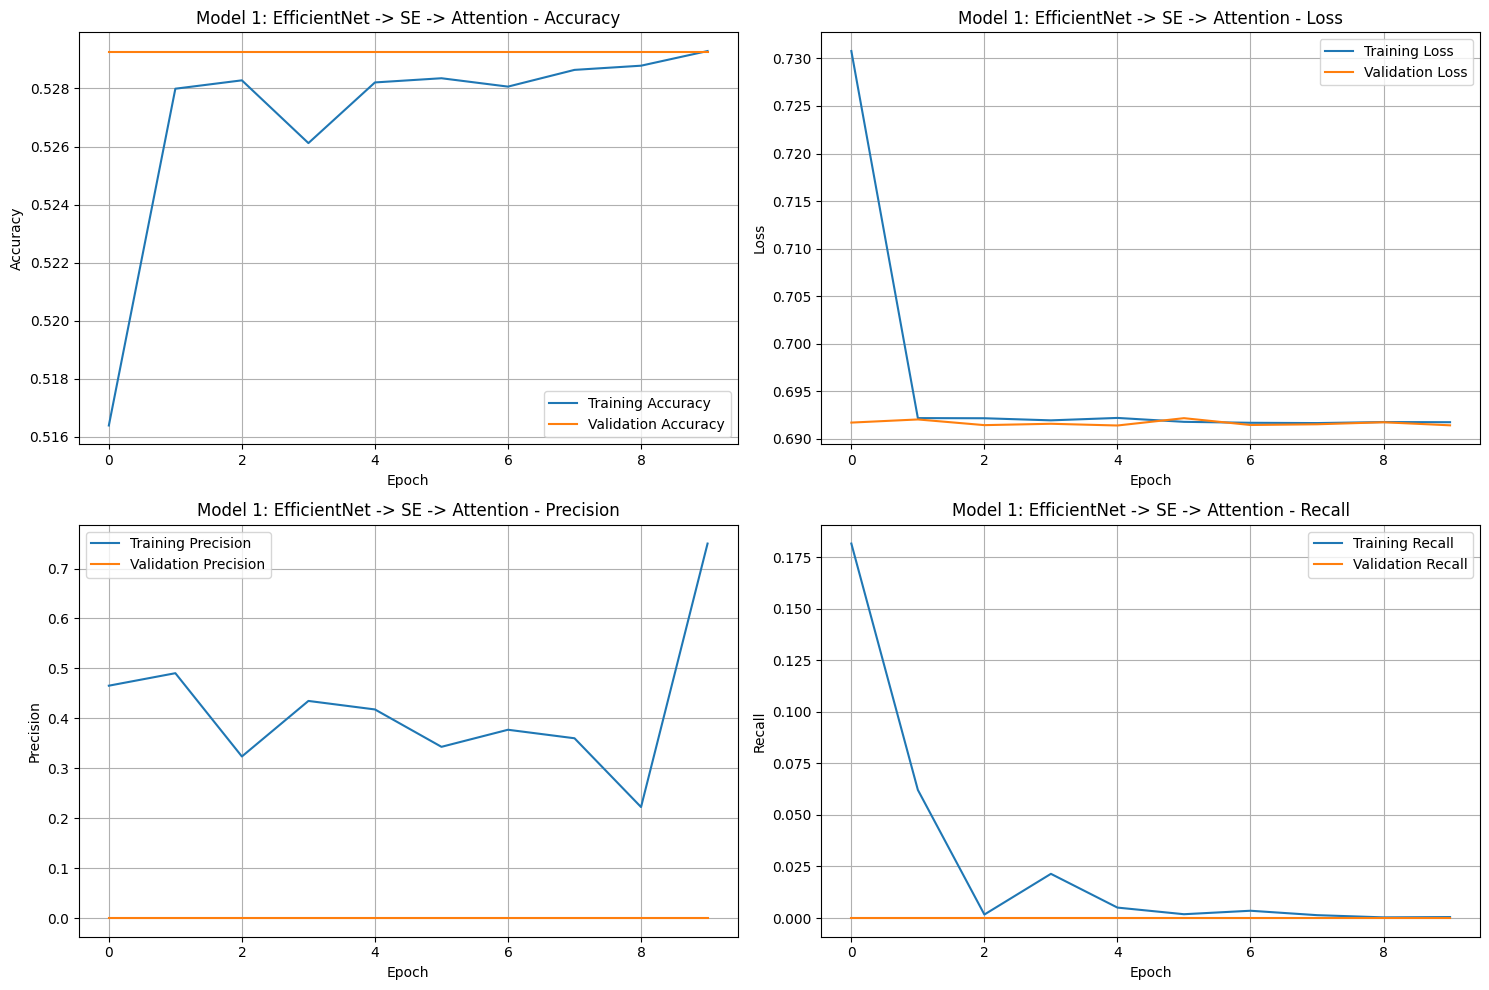

📊 Evaluating Model 1...
109/109 ━━━━━━━━━━━━━━━━━━━━ 23s 149ms/step
✅ Model 1 Evaluation Results:
   - Accuracy: 0.5293
   - Precision: 0.0000
   - Recall: 0.0000
   - F1-Score: 0.0000
   - ROC AUC: 0.6637
   - PR AUC: 0.6085


In [29]:
# Cell 7: Train Model 1 (FIXED)
# =========================================
# 6️⃣ Model 1 Training: EfficientNet -> SE -> Attention (FIXED)
# =========================================

if train_gen is not None and val_gen is not None:
    # Create and train Model 1
    model_1 = create_model_1_eff_se_att(input_shape=img_size + (3,))
    print(f"📋 Model 1 Summary:")
    model_1.summary()

    # Train the model
    history_1 = compile_and_train_model(
        model_1, train_gen, val_gen,
        "Model_1_EfficientNet_SE_Attention",
        epochs=15
    )

    # Plot training history
    plot_training_history(history_1, "Model 1: EfficientNet -> SE -> Attention")

    # Evaluate the model
    metrics_1 = evaluate_model(model_1, val_gen, "Model 1")

else:
    print("❌ Cannot train models: Data generators not available")

🏗️ Building Model 2: EfficientNet -> Attention -> SE -> Classifier
📋 Model 2 Summary:


Model: "EfficientNet_Attention_SE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_4[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1, 1,      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1, 1,      │          0 │ efficientnetb0[0… │
│ (GlobalMaxPooling2… │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1, 1, 160) │    204,960 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 1, 1, 160) │    204,960 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1, 1,      │    206,080 │ dense_16[0][0]    │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 1, 1,      │    206,080 │ dense_18[0][0]    │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1, 1,      │          0 │ dense_17[0][0],   │
│                     │ 1280)             │            │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 7, 7,      │          0 │ efficientnetb0[0… │
│ (Multiply)          │ 1280)             │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 7, 7, 2)   │          0 │ lambda_4[0][0],   │
│ (Concatenate)       │                   │            │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 1)   │         98 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_7          │ (None, 7, 7,      │          0 │ multiply_6[0][0], │
│ (Multiply)          │ 1280)             │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply_7[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 1, 1, 160) │    204,800 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 1, 1,      │    204,800 │ dense_20[0][0]  

 Total params: 5,939,782 (22.66 MB)

 Trainable params: 1,889,187 (7.21 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

🎯 Training Model_2_EfficientNet_Attention_SE...
Epoch 1/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 262s 547ms/step - accuracy: 0.5078 - loss: 0.7343 - precision: 0.4657 - recall: 0.2754 - val_accuracy: 0.5293 - val_loss: 0.6916 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 211s 487ms/step - accuracy: 0.5307 - loss: 0.6925 - precision: 0.3985 - recall: 0.0069 - val_accuracy: 0.4707 - val_loss: 0.6934 - val_precision: 0.4707 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 210s 483ms/step - accuracy: 0.5290 - loss: 0.6919 - precision: 0.4911 - recall: 0.0386 - val_accuracy: 0.4707 - val_loss: 0.6935 - val_precision: 0.4707 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 213s 490ms/step - accuracy: 0.5315 - loss: 0.6920 - precision: 0.4539 - recall: 0.0123 - val_accuracy: 0.5293 - val_loss: 0.6915 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learni

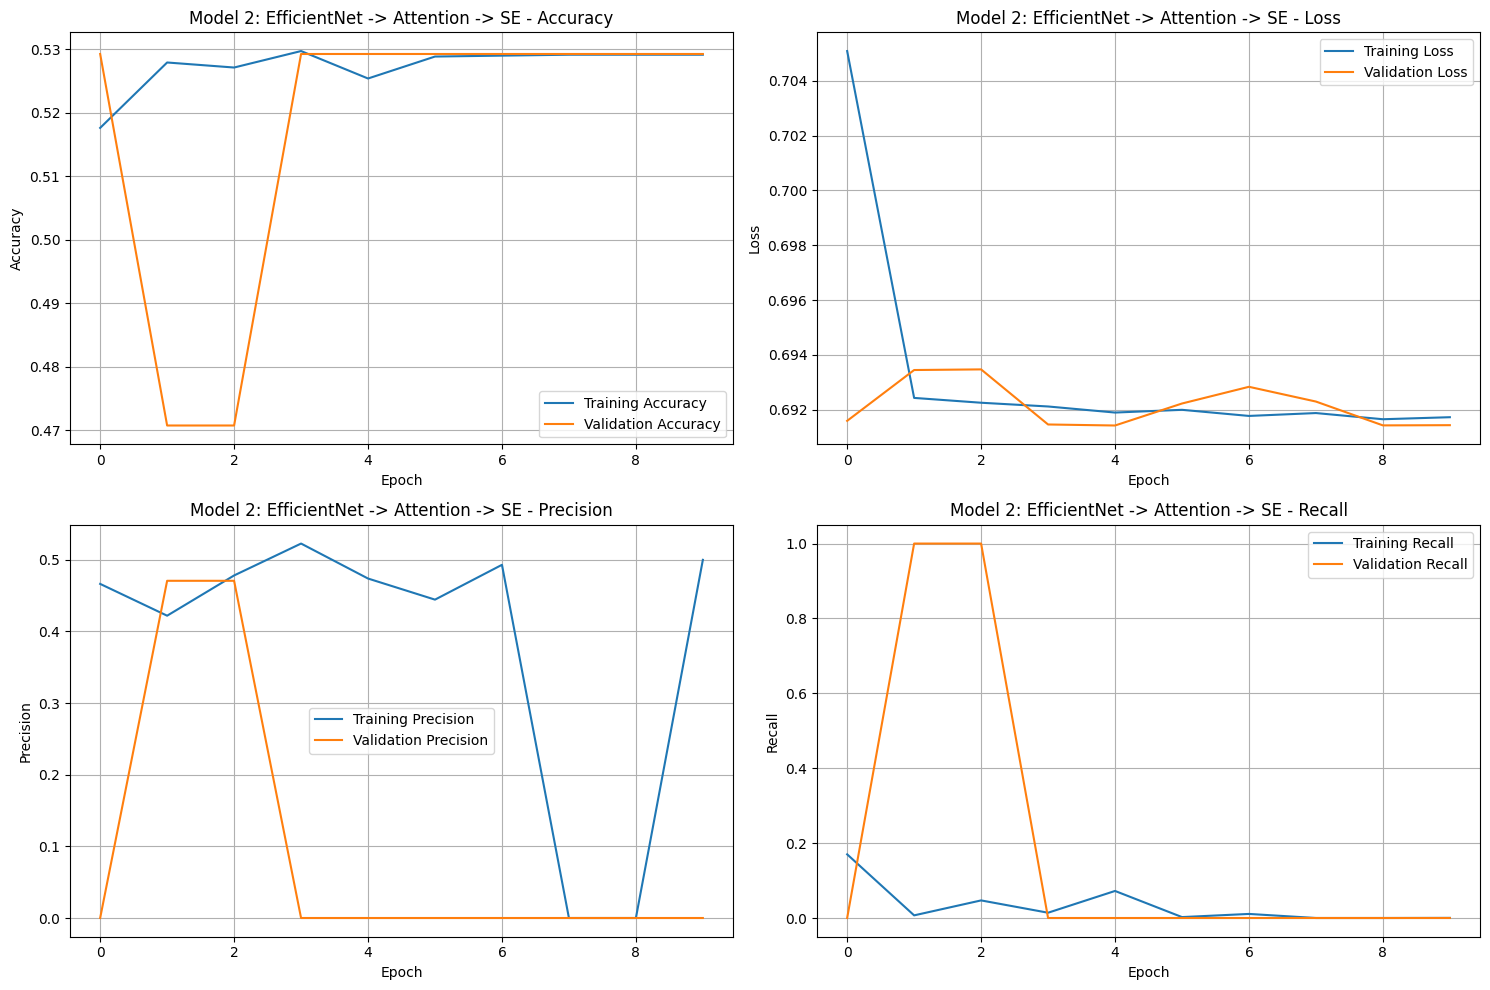

📊 Evaluating Model 2...
109/109 ━━━━━━━━━━━━━━━━━━━━ 24s 151ms/step
✅ Model 2 Evaluation Results:
   - Accuracy: 0.5293
   - Precision: 0.0000
   - Recall: 0.0000
   - F1-Score: 0.0000
   - ROC AUC: 0.6364
   - PR AUC: 0.6183


In [30]:
# Cell 8: Train Model 2
# =========================================
# 7️⃣ Model 2 Training: EfficientNet -> Attention -> SE
# =========================================

if train_gen is not None and val_gen is not None:
    # Create and train Model 2
    model_2 = create_model_2_eff_att_se(input_shape=img_size + (3,))
    print(f"📋 Model 2 Summary:")
    model_2.summary()

    # Train the model
    history_2 = compile_and_train_model(
        model_2, train_gen, val_gen,
        "Model_2_EfficientNet_Attention_SE",
        epochs=15
    )

    # Plot training history
    plot_training_history(history_2, "Model 2: EfficientNet -> Attention -> SE")

    # Evaluate the model
    metrics_2 = evaluate_model(model_2, val_gen, "Model 2")

else:
    print("❌ Cannot train models: Data generators not available")

🏗️ Building Model 3: SE -> EfficientNet -> Attention -> Classifier
📋 Model 3 Summary:


Model: "SE_EfficientNet_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │        896 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_3[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 1, 32)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 1, 1, 4)   │        128 │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 1, 1, 32)  │        128 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_9          │ (None, 224, 224,  │          0 │ conv2d_3[0][0],   │
│ (Multiply)          │ 32)               │            │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 224, 224,  │          0 │ multiply_9[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 224, 224,  │         99 │ lambda_6[0][0]    │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ conv2d_4[0][0]    │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1, 1,      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1, 1,      │          0 │ efficientnetb0[0… │
│ (GlobalMaxPooling2… │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 1, 1, 160) │    204,960 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 1, 1, 160) │    204,960 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 1, 1,      │    206,080 │ dense_26[0][0]    │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 1, 1,      │    206,080 │ dense_28[0][0]    │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 1, 1,      │          0 │ dense_27[0][0],   │
│                     │ 1280)             │            │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_10         │ (None, 7, 7,      │          0 │ efficientnetb0[0… │
│ (Multiply)          │ 1280)             │            │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,531,433 (21.10 MB)

 Trainable params: 1,480,838 (5.65 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

🎯 Training Model_3_SE_EfficientNet_Attention...
Epoch 1/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 291s 591ms/step - accuracy: 0.5059 - loss: 0.7747 - precision: 0.4682 - recall: 0.3390 - val_accuracy: 0.5293 - val_loss: 0.6916 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 226s 519ms/step - accuracy: 0.5310 - loss: 0.6900 - precision: 0.5088 - recall: 0.1606 - val_accuracy: 0.5252 - val_loss: 0.6935 - val_precision: 0.4878 - val_recall: 0.1721 - learning_rate: 0.0010
Epoch 3/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 227s 522ms/step - accuracy: 0.5406 - loss: 0.6886 - precision: 0.5275 - recall: 0.2802 - val_accuracy: 0.4462 - val_loss: 0.7227 - val_precision: 0.4521 - val_recall: 0.8322 - learning_rate: 0.0010
Epoch 4/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 228s 525ms/step - accuracy: 0.5836 - loss: 0.6749 - precision: 0.5832 - recall: 0.3767 - val_accuracy: 0.5321 - val_loss: 0.6928 - val_precision: 0.5044 - val_recall: 0.3515 - learning_rate:

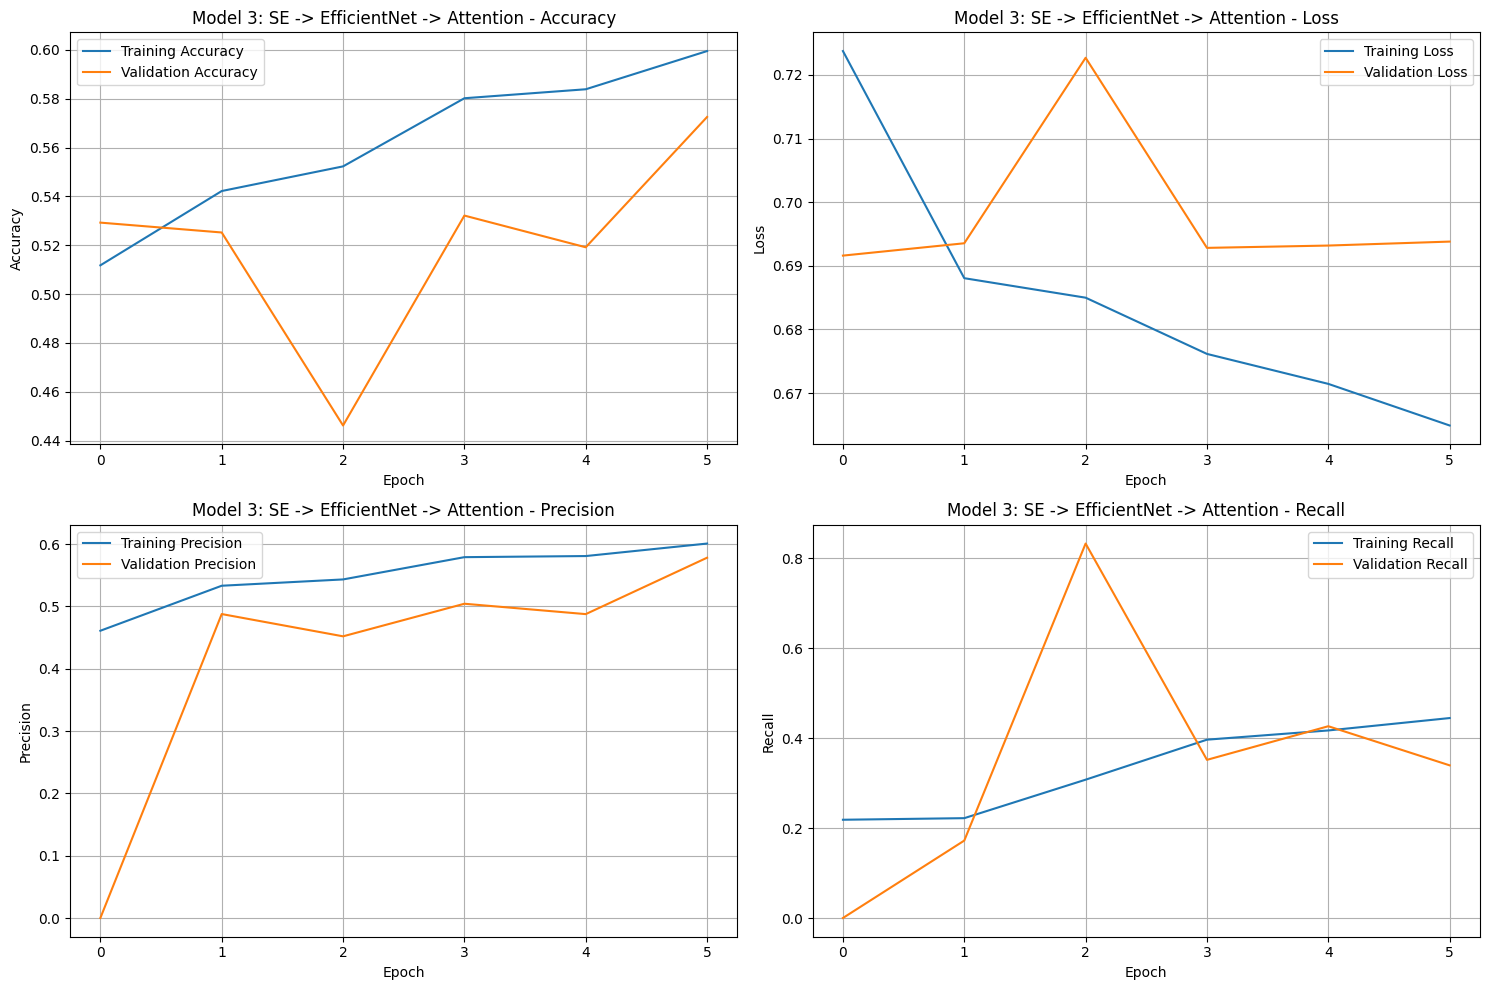

📊 Evaluating Model 3...
109/109 ━━━━━━━━━━━━━━━━━━━━ 24s 163ms/step
✅ Model 3 Evaluation Results:
   - Accuracy: 0.5293
   - Precision: 0.0000
   - Recall: 0.0000
   - F1-Score: 0.0000
   - ROC AUC: 0.6037
   - PR AUC: 0.5818


In [31]:
# Cell 9: Train Model 3
# =========================================
# 8️⃣ Model 3 Training: SE -> EfficientNet -> Attention
# =========================================

if train_gen is not None and val_gen is not None:
    # Create and train Model 3
    model_3 = create_model_3_se_eff_att(input_shape=img_size + (3,))
    print(f"📋 Model 3 Summary:")
    model_3.summary()

    # Train the model
    history_3 = compile_and_train_model(
        model_3, train_gen, val_gen,
        "Model_3_SE_EfficientNet_Attention",
        epochs=15
    )

    # Plot training history
    plot_training_history(history_3, "Model 3: SE -> EfficientNet -> Attention")

    # Evaluate the model
    metrics_3 = evaluate_model(model_3, val_gen, "Model 3")

else:
    print("❌ Cannot train models: Data generators not available")

🏗️ Building Model 4: Attention -> EfficientNet -> SE -> Classifier
📋 Model 4 Summary:


Model: "Attention_EfficientNet_SE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 224, 224,  │        896 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1, 1, 32)  │          0 │ conv2d_6[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1, 1, 32)  │          0 │ conv2d_6[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 1, 1, 4)   │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 1, 1, 4)   │        132 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 1, 1, 32)  │        160 │ dense_32[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 1, 1, 32)  │        160 │ dense_34[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 1, 1, 32)  │          0 │ dense_33[0][0],   │
│                     │                   │            │ dense_35[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_12         │ (None, 224, 224,  │          0 │ conv2d_6[0][0],   │
│ (Multiply)          │ 32)               │            │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 224, 224,  │          0 │ multiply_12[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_10 (Lambda)  │ (None, 224, 224,  │          0 │ multiply_12[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 224, 224,  │          0 │ lambda_9[0][0],   │
│ (Concatenate)       │ 2)                │            │ lambda_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 224, 224,  │         98 │ concatenate_4[0]… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_13         │ (None, 224, 224,  │          0 │ multiply_12[0][0… │
│ (Multiply)          │ 32)               │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_11 (Lambda)  │ (None, 224, 224,  │          0 │ multiply_13[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 224, 224,  │         99 │ lambda_11[0][0]   │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ conv2d_8[0][0]    │
│ (Functional)        │ 1280)             │            │                 

 Total params: 5,119,281 (19.53 MB)

 Trainable params: 1,068,686 (4.08 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

🎯 Training Model_4_Attention_EfficientNet_SE...
Epoch 1/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 288s 594ms/step - accuracy: 0.4952 - loss: 0.8427 - precision: 0.4588 - recall: 0.4407 - val_accuracy: 0.4748 - val_loss: 0.7272 - val_precision: 0.4726 - val_recall: 0.9976 - learning_rate: 0.0010
Epoch 2/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 230s 529ms/step - accuracy: 0.5438 - loss: 0.6949 - precision: 0.5240 - recall: 0.4820 - val_accuracy: 0.5950 - val_loss: 0.6586 - val_precision: 0.6707 - val_recall: 0.2743 - learning_rate: 0.0010
Epoch 3/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 227s 522ms/step - accuracy: 0.6496 - loss: 0.6248 - precision: 0.6374 - recall: 0.5836 - val_accuracy: 0.6685 - val_loss: 0.6514 - val_precision: 0.6447 - val_recall: 0.6589 - learning_rate: 0.0010
Epoch 4/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 227s 523ms/step - accuracy: 0.7435 - loss: 0.5204 - precision: 0.7342 - recall: 0.7102 - val_accuracy: 0.6812 - val_loss: 0.6662 - val_precision: 0.7148 - val_recall: 0.5370 - learning_rate: 0.0010


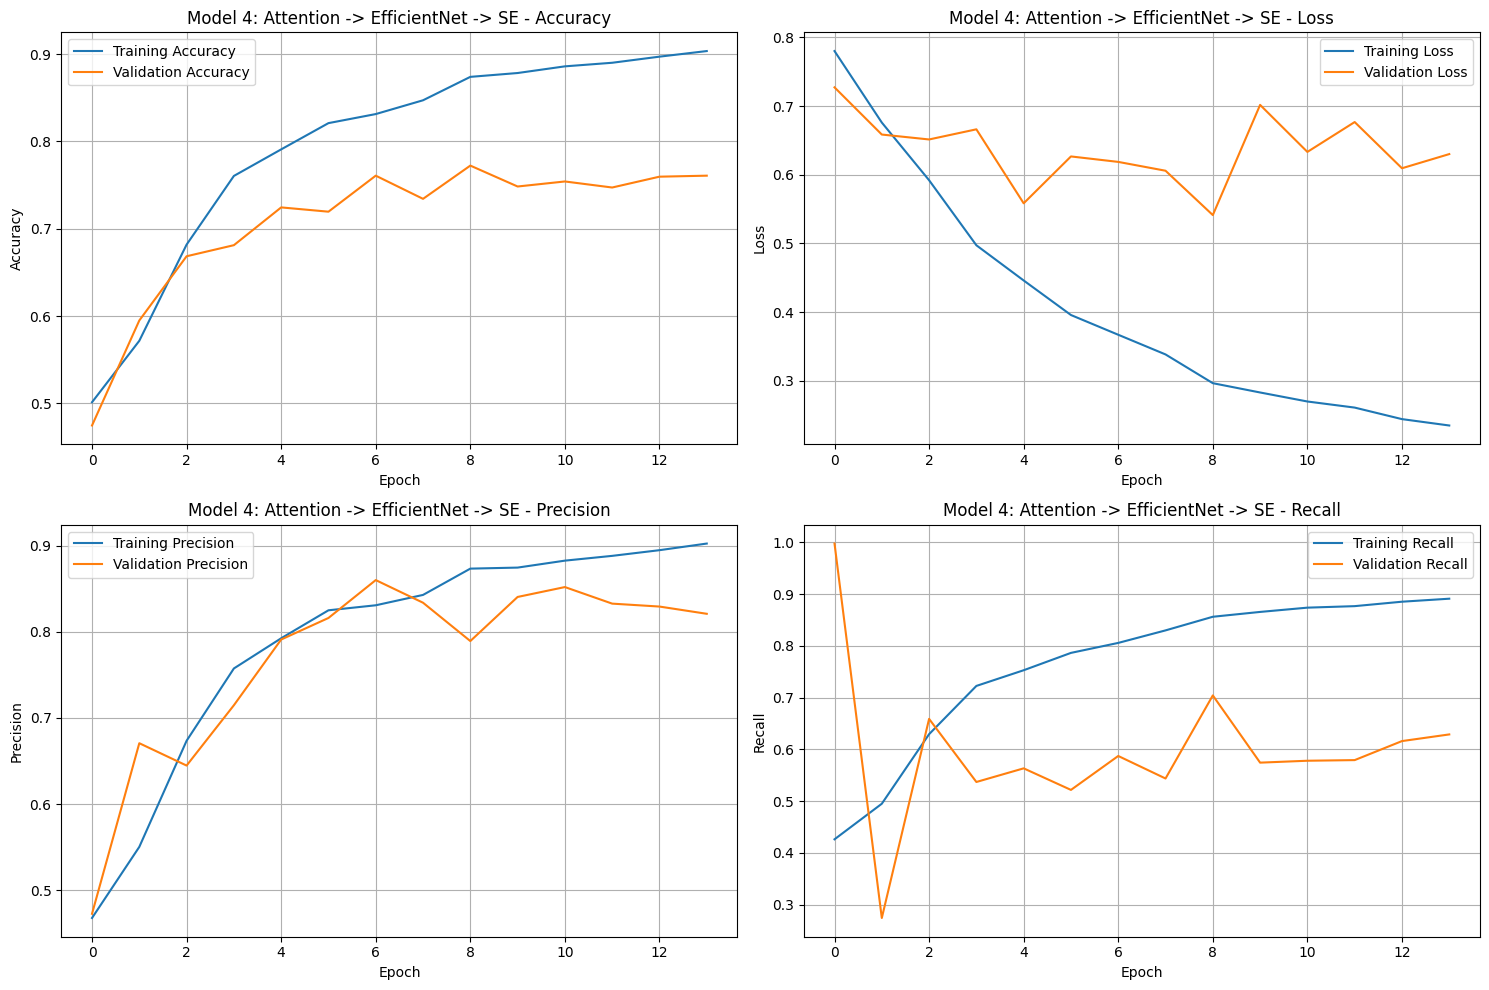

📊 Evaluating Model 4...
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 169ms/step
✅ Model 4 Evaluation Results:
   - Accuracy: 0.7723
   - Precision: 0.7893
   - Recall: 0.7042
   - F1-Score: 0.7443
   - ROC AUC: 0.8560
   - PR AUC: 0.8404


In [32]:
# Cell 10: Train Model 4
# =========================================
# 9️⃣ Model 4 Training: Attention -> EfficientNet -> SE
# =========================================

if train_gen is not None and val_gen is not None:
    # Create and train Model 4
    model_4 = create_model_4_att_eff_se(input_shape=img_size + (3,))
    print(f"📋 Model 4 Summary:")
    model_4.summary()

    # Train the model
    history_4 = compile_and_train_model(
        model_4, train_gen, val_gen,
        "Model_4_Attention_EfficientNet_SE",
        epochs=15
    )

    # Plot training history
    plot_training_history(history_4, "Model 4: Attention -> EfficientNet -> SE")

    # Evaluate the model
    metrics_4 = evaluate_model(model_4, val_gen, "Model 4")

else:
    print("❌ Cannot train models: Data generators not available")

🏗️ Building Model 5: SE -> Attention -> EfficientNet -> Classifier
📋 Model 5 Summary:


Model: "SE_Attention_EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 224, 224,  │        896 │ input_layer_10[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_9[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 1, 1, 32)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 1, 1, 4)   │        128 │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 1, 1, 32)  │        128 │ dense_40[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_15         │ (None, 224, 224,  │          0 │ conv2d_9[0][0],   │
│ (Multiply)          │ 32)               │            │ dense_41[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1, 1, 32)  │          0 │ multiply_15[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1, 1, 32)  │          0 │ multiply_15[0][0] │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 1, 1, 4)   │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 1, 1, 4)   │        132 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 1, 1, 32)  │        160 │ dense_42[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 1, 1, 32)  │        160 │ dense_44[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 1, 1, 32)  │          0 │ dense_43[0][0],   │
│                     │                   │            │ dense_45[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_16         │ (None, 224, 224,  │          0 │ multiply_15[0][0… │
│ (Multiply)          │ 32)               │            │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_12 (Lambda)  │ (None, 224, 224,  │          0 │ multiply_16[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_13 (Lambda)  │ (None, 224, 224,  │          0 │ multiply_16[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 224, 224,  │          0 │ lambda_12[0][0],  │
│ (Concatenate)       │ 2)                │            │ lambda_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 224, 224,  │         98 │ concatenate_5[0]… │
│                     │ 1)                │            │                 

 Total params: 4,709,937 (17.97 MB)

 Trainable params: 659,342 (2.52 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

🎯 Training Model_5_SE_Attention_EfficientNet...
Epoch 1/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 288s 596ms/step - accuracy: 0.5073 - loss: 0.8616 - precision: 0.4734 - recall: 0.4514 - val_accuracy: 0.5293 - val_loss: 0.6973 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 226s 521ms/step - accuracy: 0.5053 - loss: 0.7039 - precision: 0.4729 - recall: 0.3417 - val_accuracy: 0.5333 - val_loss: 0.6886 - val_precision: 0.5055 - val_recall: 0.3907 - learning_rate: 0.0010
Epoch 3/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 226s 520ms/step - accuracy: 0.5743 - loss: 0.6804 - precision: 0.5694 - recall: 0.4013 - val_accuracy: 0.5359 - val_loss: 0.6716 - val_precision: 0.5108 - val_recall: 0.3331 - learning_rate: 0.0010
Epoch 4/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 224s 516ms/step - accuracy: 0.5912 - loss: 0.6658 - precision: 0.5833 - recall: 0.4221 - val_accuracy: 0.5705 - val_loss: 0.6840 - val_precision: 0.5648 - val_recall: 0.3815 - learning_rate:

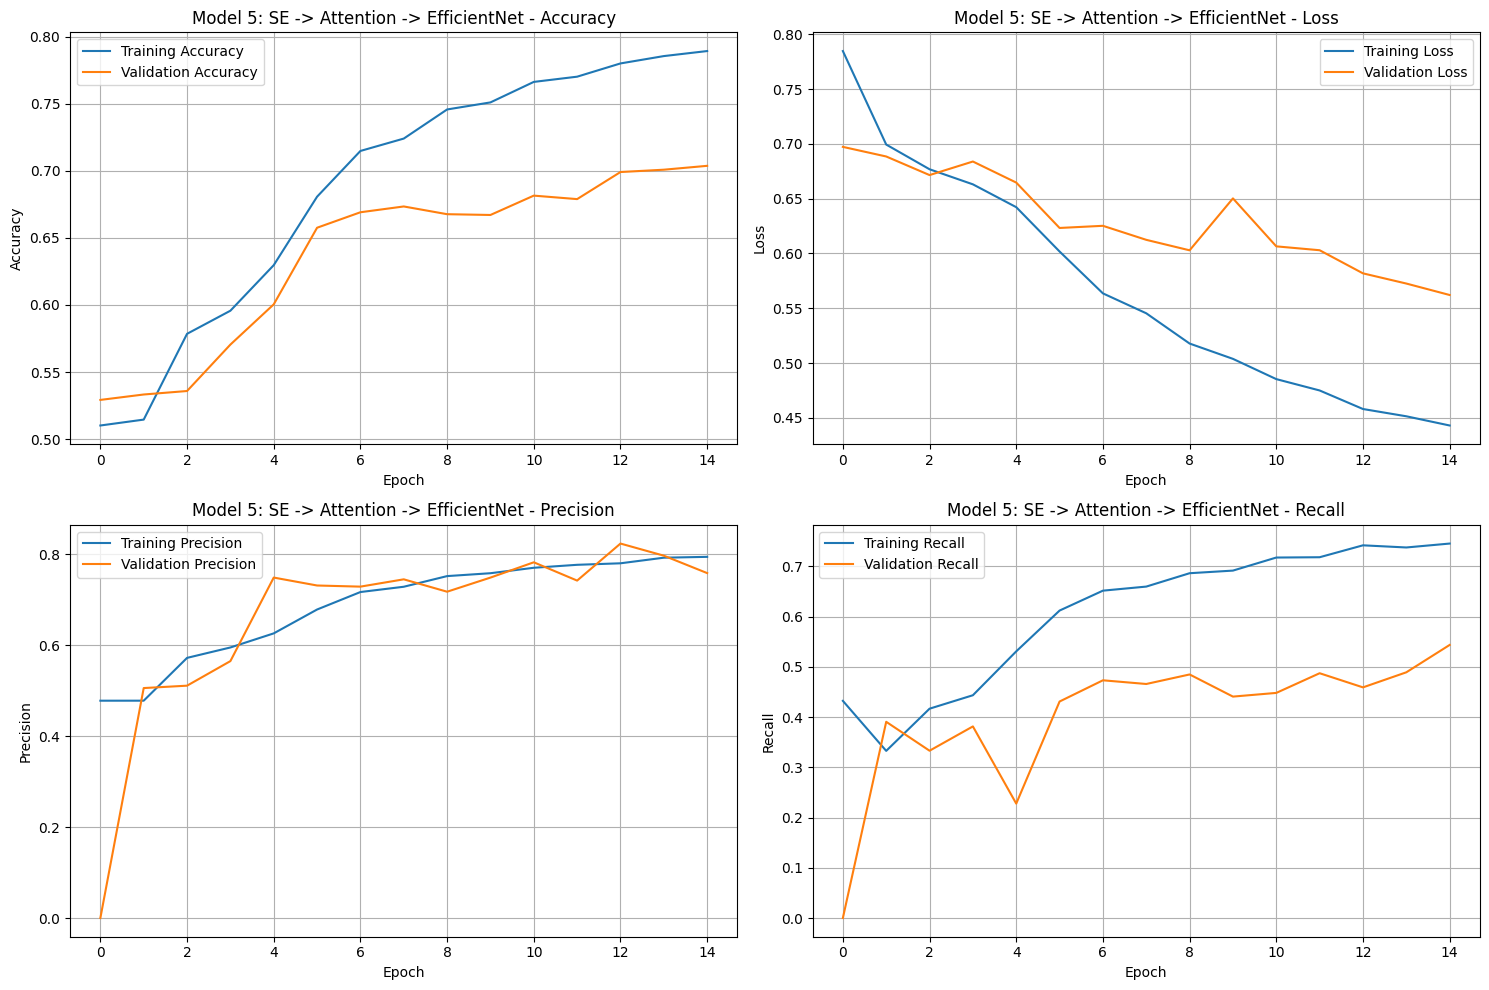

📊 Evaluating Model 5...
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 165ms/step
✅ Model 5 Evaluation Results:
   - Accuracy: 0.7037
   - Precision: 0.7583
   - Recall: 0.5438
   - F1-Score: 0.6334
   - ROC AUC: 0.8014
   - PR AUC: 0.7653


In [33]:
# Cell 11: Train Model 5
# =========================================
# 🔟 Model 5 Training: SE -> Attention -> EfficientNet
# =========================================

if train_gen is not None and val_gen is not None:
    # Create and train Model 5
    model_5 = create_model_5_se_att_eff(input_shape=img_size + (3,))
    print(f"📋 Model 5 Summary:")
    model_5.summary()

    # Train the model
    history_5 = compile_and_train_model(
        model_5, train_gen, val_gen,
        "Model_5_SE_Attention_EfficientNet",
        epochs=15
    )

    # Plot training history
    plot_training_history(history_5, "Model 5: SE -> Attention -> EfficientNet")

    # Evaluate the model
    metrics_5 = evaluate_model(model_5, val_gen, "Model 5")

else:
    print("❌ Cannot train models: Data generators not available")

🏗️ Building Model 6: Attention -> SE -> EfficientNet -> Classifier
📋 Model 6 Summary:


Model: "Attention_SE_EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 224, 224,  │        896 │ input_layer_12[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1, 1, 32)  │          0 │ conv2d_12[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1, 1, 32)  │          0 │ conv2d_12[0][0]   │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 1, 1, 4)   │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 1, 1, 4)   │        132 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 1, 1, 32)  │        160 │ dense_48[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_51 (Dense)    │ (None, 1, 1, 32)  │        160 │ dense_50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 1, 1, 32)  │          0 │ dense_49[0][0],   │
│                     │                   │            │ dense_51[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_18         │ (None, 224, 224,  │          0 │ conv2d_12[0][0],  │
│ (Multiply)          │ 32)               │            │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_15 (Lambda)  │ (None, 224, 224,  │          0 │ multiply_18[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_16 (Lambda)  │ (None, 224, 224,  │          0 │ multiply_18[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 224, 224,  │          0 │ lambda_15[0][0],  │
│ (Concatenate)       │ 2)                │            │ lambda_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 224, 224,  │         98 │ concatenate_6[0]… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_19         │ (None, 224, 224,  │          0 │ multiply_18[0][0… │
│ (Multiply)          │ 32)               │            │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ multiply_19[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 1, 1, 32)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 1, 1, 4)   │        128 │ reshape_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 1, 1, 32)  │        128 │ dense_52[0][0]  

 Total params: 4,709,937 (17.97 MB)

 Trainable params: 659,342 (2.52 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

🎯 Training Model_6_Attention_SE_EfficientNet...
Epoch 1/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 288s 595ms/step - accuracy: 0.5082 - loss: 0.8549 - precision: 0.4668 - recall: 0.4443 - val_accuracy: 0.5298 - val_loss: 0.6874 - val_precision: 0.5278 - val_recall: 0.0116 - learning_rate: 0.0010
Epoch 2/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 228s 525ms/step - accuracy: 0.5424 - loss: 0.6915 - precision: 0.5191 - recall: 0.4486 - val_accuracy: 0.5065 - val_loss: 0.6882 - val_precision: 0.4722 - val_recall: 0.4103 - learning_rate: 0.0010
Epoch 3/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 225s 519ms/step - accuracy: 0.5843 - loss: 0.6702 - precision: 0.5650 - recall: 0.5142 - val_accuracy: 0.5555 - val_loss: 0.9168 - val_precision: 0.6022 - val_recall: 0.1641 - learning_rate: 0.0010
Epoch 4/15
434/434 ━━━━━━━━━━━━━━━━━━━━ 227s 523ms/step - accuracy: 0.6406 - loss: 0.6362 - precision: 0.6217 - recall: 0.5925 - val_accuracy: 0.6091 - val_loss: 0.7270 - val_precision: 0.6456 - val_recall: 0.3760 - learning_rate: 0.0010


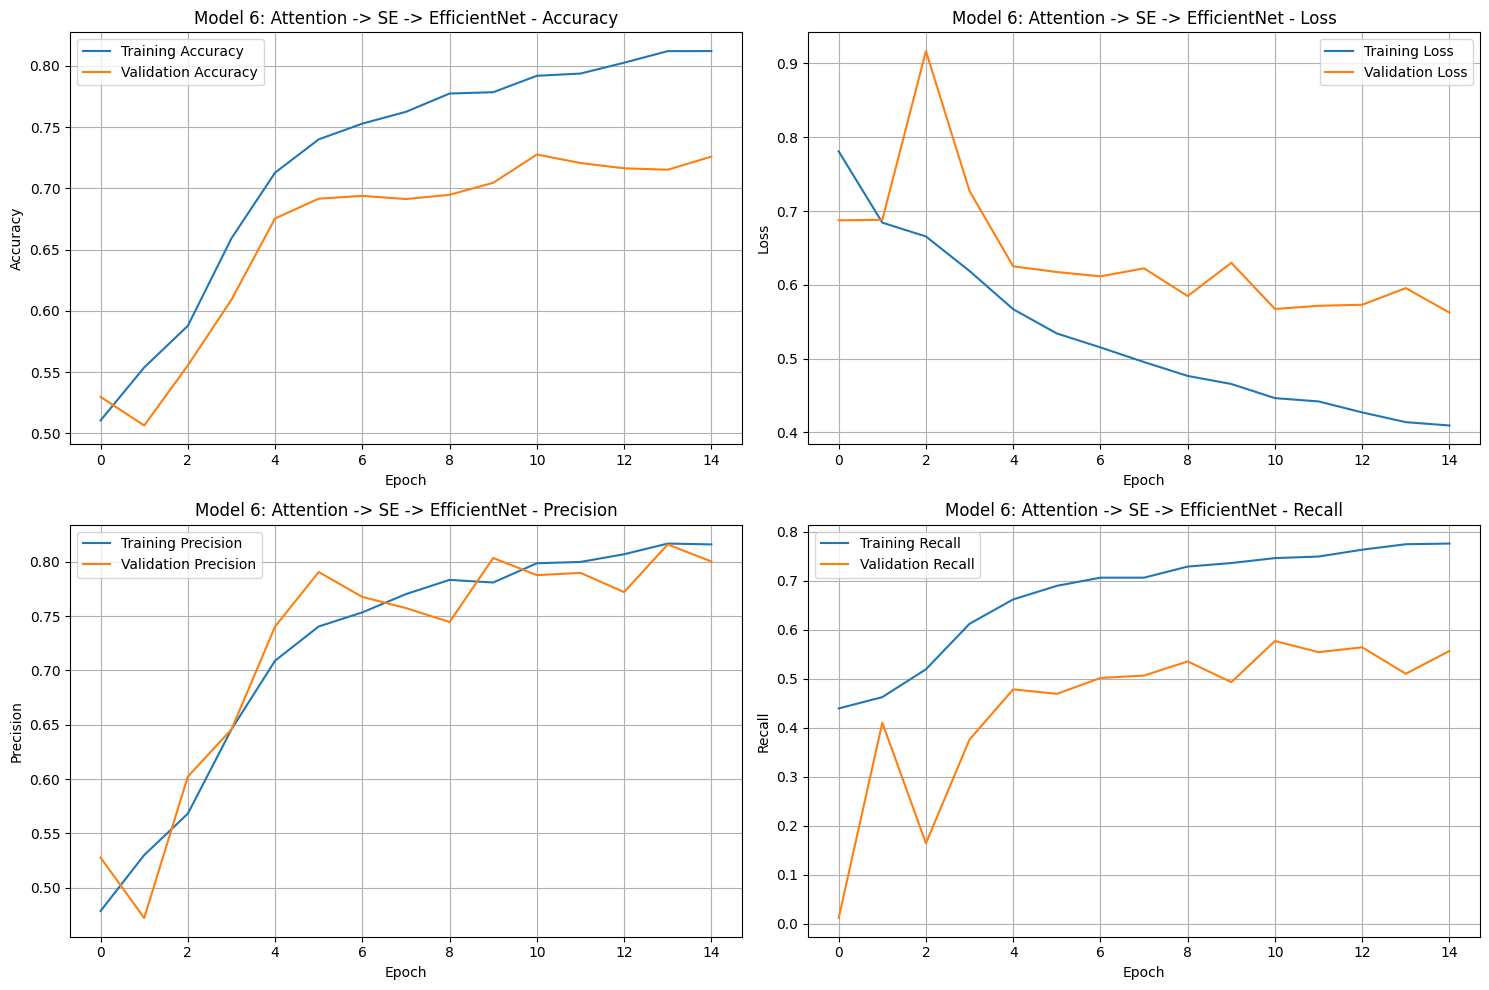

📊 Evaluating Model 6...
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 168ms/step
✅ Model 6 Evaluation Results:
   - Accuracy: 0.7259
   - Precision: 0.8002
   - Recall: 0.5566
   - F1-Score: 0.6566
   - ROC AUC: 0.8081
   - PR AUC: 0.7971


In [34]:
# Cell 12: Train Model 6
# =========================================
# 1️⃣1️⃣ Model 6 Training: Attention -> SE -> EfficientNet
# =========================================

if train_gen is not None and val_gen is not None:
    # Create and train Model 6
    model_6 = create_model_6_att_se_eff(input_shape=img_size + (3,))
    print(f"📋 Model 6 Summary:")
    model_6.summary()

    # Train the model
    history_6 = compile_and_train_model(
        model_6, train_gen, val_gen,
        "Model_6_Attention_SE_EfficientNet",
        epochs=15
    )

    # Plot training history
    plot_training_history(history_6, "Model 6: Attention -> SE -> EfficientNet")

    # Evaluate the model
    metrics_6 = evaluate_model(model_6, val_gen, "Model 6")

else:
    print("❌ Cannot train models: Data generators not available")

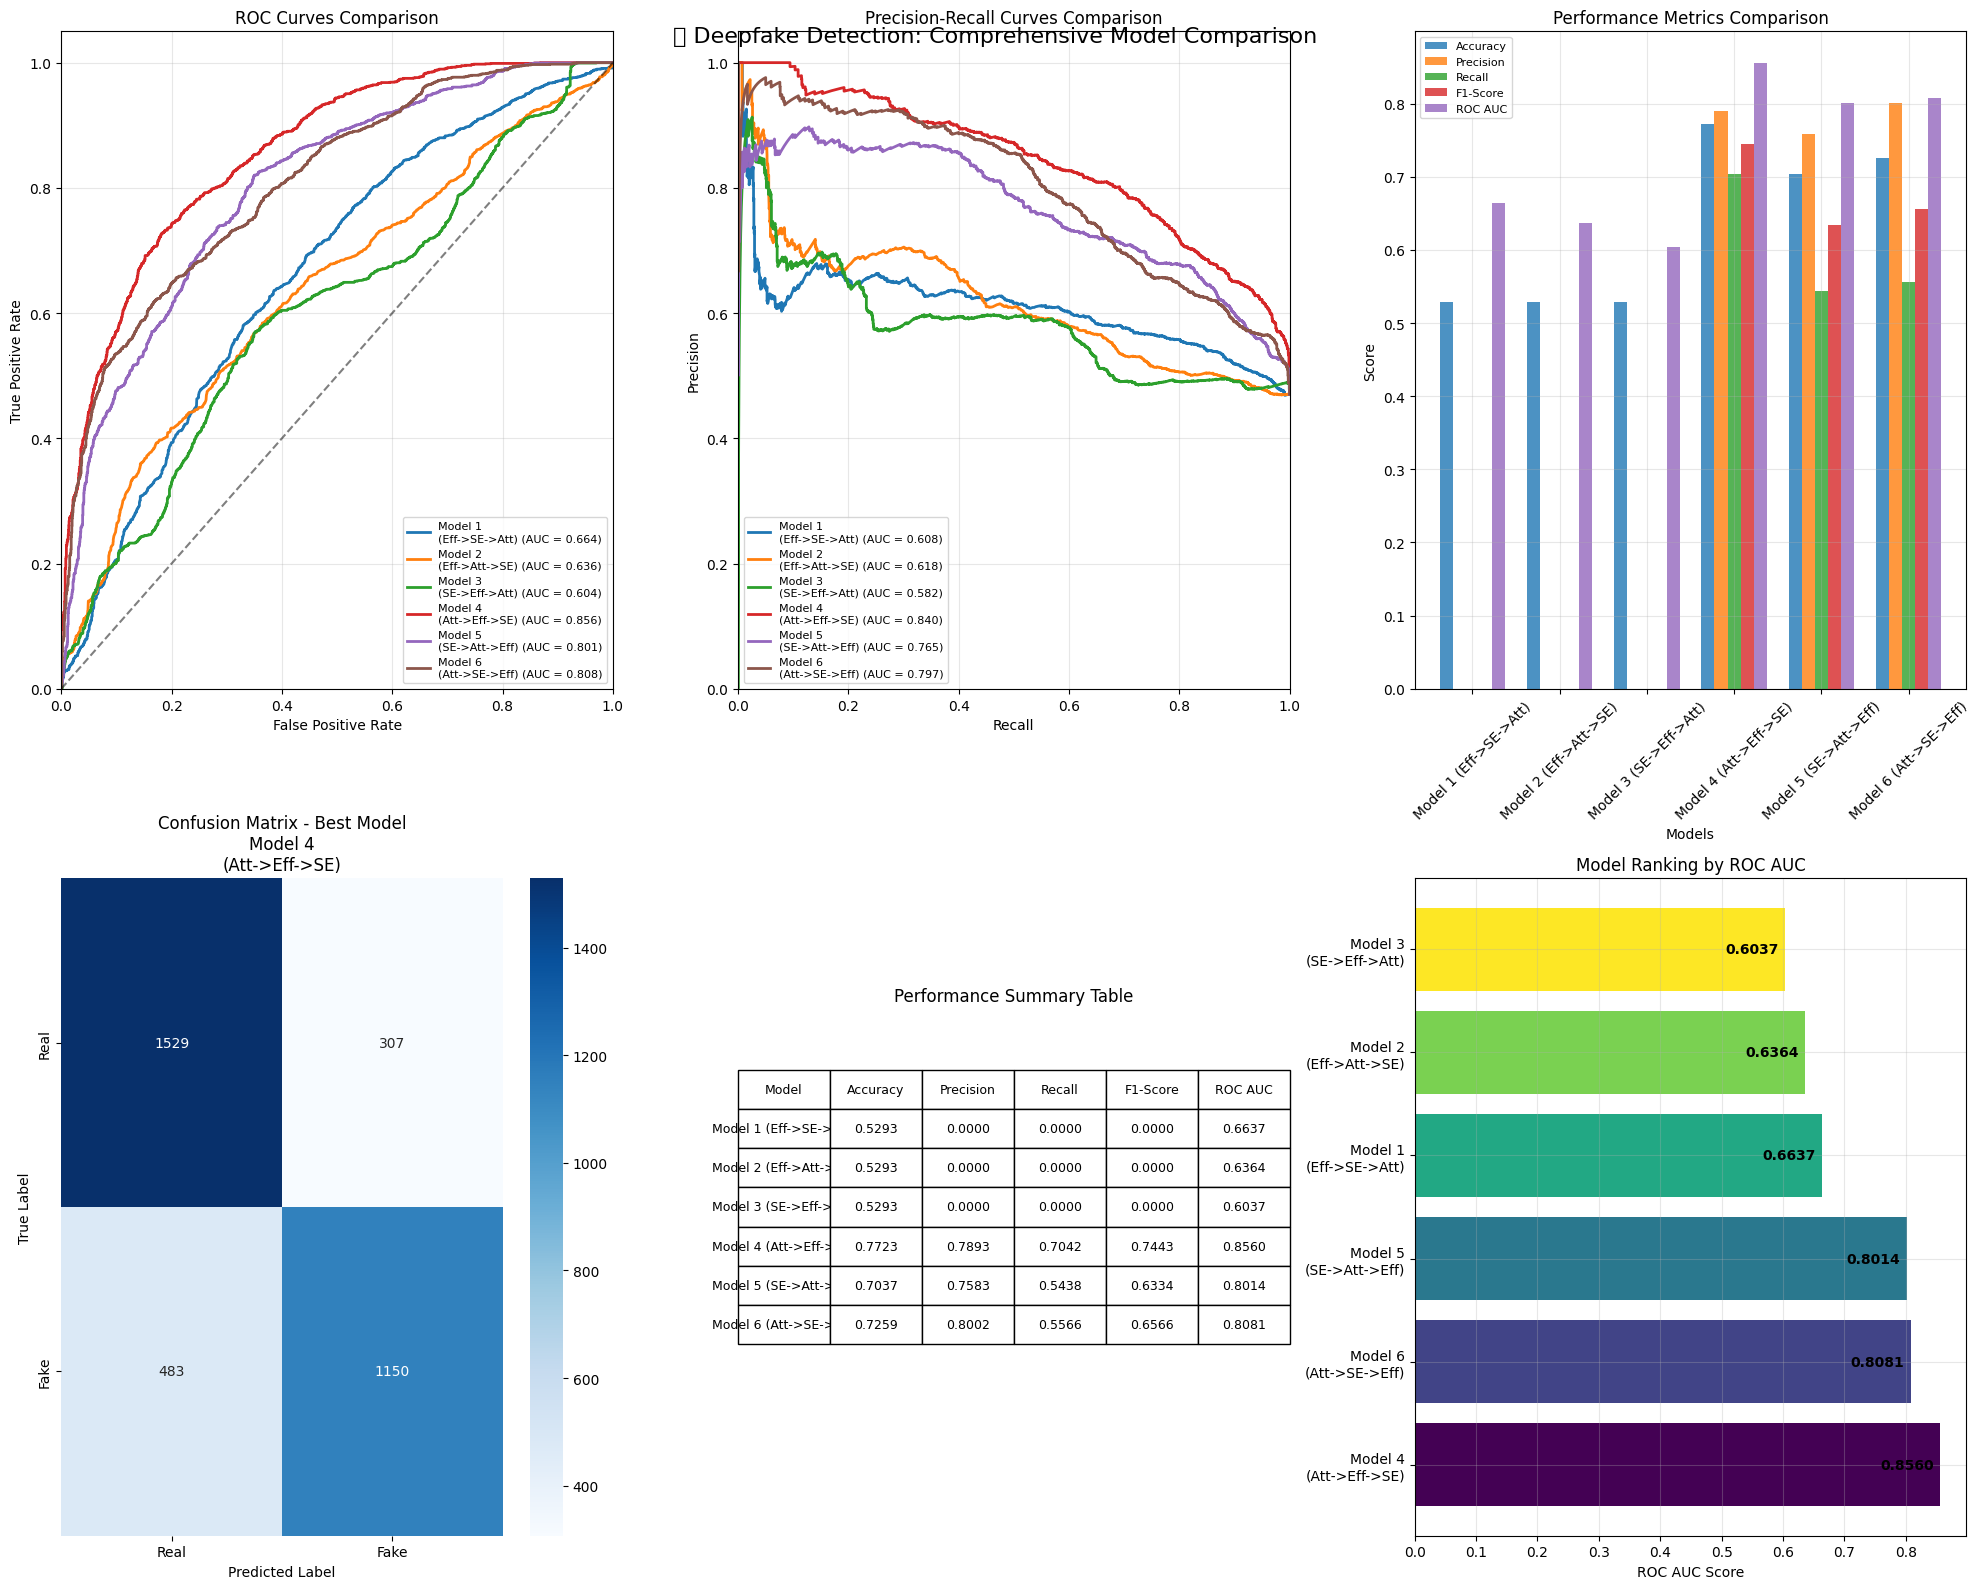

🏆 FINAL RESULTS SUMMARY
🥇 BEST MODEL: Model 4 (Att->Eff->SE)
   - ROC AUC: 0.8560
   - Accuracy: 0.7723
   - F1-Score: 0.7443

📊 ALL MODELS RANKING:
   1. Model 4 (Att->Eff->SE): ROC AUC = 0.8560
   2. Model 6 (Att->SE->Eff): ROC AUC = 0.8081
   3. Model 5 (SE->Att->Eff): ROC AUC = 0.8014
   4. Model 1 (Eff->SE->Att): ROC AUC = 0.6637
   5. Model 2 (Eff->Att->SE): ROC AUC = 0.6364
   6. Model 3 (SE->Eff->Att): ROC AUC = 0.6037

🔍 KEY INSIGHTS:
   - Average ROC AUC for SE-priority models: 0.6896
   - Average ROC AUC for Attention-priority models: 0.7668
   - 💡 Attention modules tend to perform better when placed earlier in the architecture


In [35]:
# Cell 13: Comprehensive Evaluation and Visualization
# =========================================
# 1️⃣2️⃣ Comprehensive Model Comparison and Visualization
# =========================================

def plot_comprehensive_comparison():
    """Plot comprehensive comparison of all models"""

    # Check if all metrics are available
    try:
        all_metrics = [metrics_1, metrics_2, metrics_3, metrics_4, metrics_5, metrics_6]
        model_names = ['Model 1\n(Eff->SE->Att)', 'Model 2\n(Eff->Att->SE)',
                      'Model 3\n(SE->Eff->Att)', 'Model 4\n(Att->Eff->SE)',
                      'Model 5\n(SE->Att->Eff)', 'Model 6\n(Att->SE->Eff)']
    except NameError:
        print("❌ Not all models have been trained yet. Please run all training cells first.")
        return

    # Create comprehensive comparison plots
    fig = plt.figure(figsize=(20, 16))

    # 1. ROC Curves
    plt.subplot(2, 3, 1)
    for i, (metrics, name) in enumerate(zip(all_metrics, model_names)):
        plt.plot(metrics['fpr'], metrics['tpr'],
                label=f"{name} (AUC = {metrics['roc_auc']:.3f})", linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Comparison')
    plt.legend(loc="lower right", fontsize=8)
    plt.grid(True, alpha=0.3)

    # 2. Precision-Recall Curves
    plt.subplot(2, 3, 2)
    for i, (metrics, name) in enumerate(zip(all_metrics, model_names)):
        plt.plot(metrics['recall_curve'], metrics['precision_curve'],
                label=f"{name} (AUC = {metrics['pr_auc']:.3f})", linewidth=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves Comparison')
    plt.legend(loc="lower left", fontsize=8)
    plt.grid(True, alpha=0.3)

    # 3. Metrics Bar Chart
    plt.subplot(2, 3, 3)
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
    x = np.arange(len(model_names))
    width = 0.15

    for i, metric in enumerate(['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']):
        values = [m[metric] for m in all_metrics]
        plt.bar(x + i * width, values, width, label=metrics_names[i], alpha=0.8)

    plt.xlabel('Models')
    plt.ylabel('Score')
    plt.title('Performance Metrics Comparison')
    plt.legend(fontsize=8)
    plt.xticks(x + width * 2, [name.replace('\n', ' ') for name in model_names], rotation=45)
    plt.grid(True, alpha=0.3)

    # 4. Confusion Matrix for Best Model
    best_model_idx = np.argmax([m['roc_auc'] for m in all_metrics])
    best_metrics = all_metrics[best_model_idx]
    best_name = model_names[best_model_idx]

    plt.subplot(2, 3, 4)
    y_pred_best = (best_metrics['predictions'] > 0.5).astype(int)
    cm = confusion_matrix(best_metrics['y_true'], y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.title(f'Confusion Matrix - Best Model\n{best_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    # 5. Performance Summary Table
    plt.subplot(2, 3, 5)
    plt.axis('tight')
    plt.axis('off')

    # Create performance table
    table_data = []
    for i, (metrics, name) in enumerate(zip(all_metrics, model_names)):
        table_data.append([
            name.replace('\n', ' '),
            f"{metrics['accuracy']:.4f}",
            f"{metrics['precision']:.4f}",
            f"{metrics['recall']:.4f}",
            f"{metrics['f1_score']:.4f}",
            f"{metrics['roc_auc']:.4f}"
        ])

    table = plt.table(cellText=table_data,
                     colLabels=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'],
                     cellLoc='center',
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    plt.title('Performance Summary Table', y=0.8)

    # 6. Model Ranking
    plt.subplot(2, 3, 6)
    roc_scores = [m['roc_auc'] for m in all_metrics]
    sorted_indices = np.argsort(roc_scores)[::-1]
    sorted_names = [model_names[i] for i in sorted_indices]
    sorted_scores = [roc_scores[i] for i in sorted_indices]

    bars = plt.barh(range(len(sorted_names)), sorted_scores,
                   color=plt.cm.viridis(np.linspace(0, 1, len(sorted_names))))
    plt.yticks(range(len(sorted_names)), sorted_names)
    plt.xlabel('ROC AUC Score')
    plt.title('Model Ranking by ROC AUC')
    plt.grid(True, alpha=0.3)

    # Add score labels on bars
    for i, (bar, score) in enumerate(zip(bars, sorted_scores)):
        plt.text(score - 0.01, bar.get_y() + bar.get_height()/2,
                f'{score:.4f}', ha='right', va='center', fontweight='bold')

    plt.tight_layout()
    plt.suptitle('🧩 Deepfake Detection: Comprehensive Model Comparison',
                fontsize=16, y=0.98)
    plt.show()

    # Print detailed summary
    print("🏆 FINAL RESULTS SUMMARY")
    print("=" * 80)

    roc_scores = [m['roc_auc'] for m in all_metrics]
    best_idx = np.argmax(roc_scores)

    print(f"🥇 BEST MODEL: {model_names[best_idx].replace(chr(10), ' ')}")
    print(f"   - ROC AUC: {all_metrics[best_idx]['roc_auc']:.4f}")
    print(f"   - Accuracy: {all_metrics[best_idx]['accuracy']:.4f}")
    print(f"   - F1-Score: {all_metrics[best_idx]['f1_score']:.4f}")

    print("\n📊 ALL MODELS RANKING:")
    for i, idx in enumerate(np.argsort(roc_scores)[::-1]):
        print(f"   {i+1}. {model_names[idx].replace(chr(10), ' ')}: ROC AUC = {roc_scores[idx]:.4f}")

    print("\n🔍 KEY INSIGHTS:")
    se_first_models = [0, 2, 4]  # Models with SE first or early
    att_first_models = [1, 3, 5]  # Models with Attention first or early

    se_avg = np.mean([roc_scores[i] for i in se_first_models])
    att_avg = np.mean([roc_scores[i] for i in att_first_models])

    print(f"   - Average ROC AUC for SE-priority models: {se_avg:.4f}")
    print(f"   - Average ROC AUC for Attention-priority models: {att_avg:.4f}")

    if se_avg > att_avg:
        print("   - 💡 SE modules tend to perform better when placed earlier in the architecture")
    else:
        print("   - 💡 Attention modules tend to perform better when placed earlier in the architecture")

# Run comprehensive comparison
if 'metrics_1' in locals():
    plot_comprehensive_comparison()
else:
    print("❌ Please run all model training cells first to generate the comparison.")

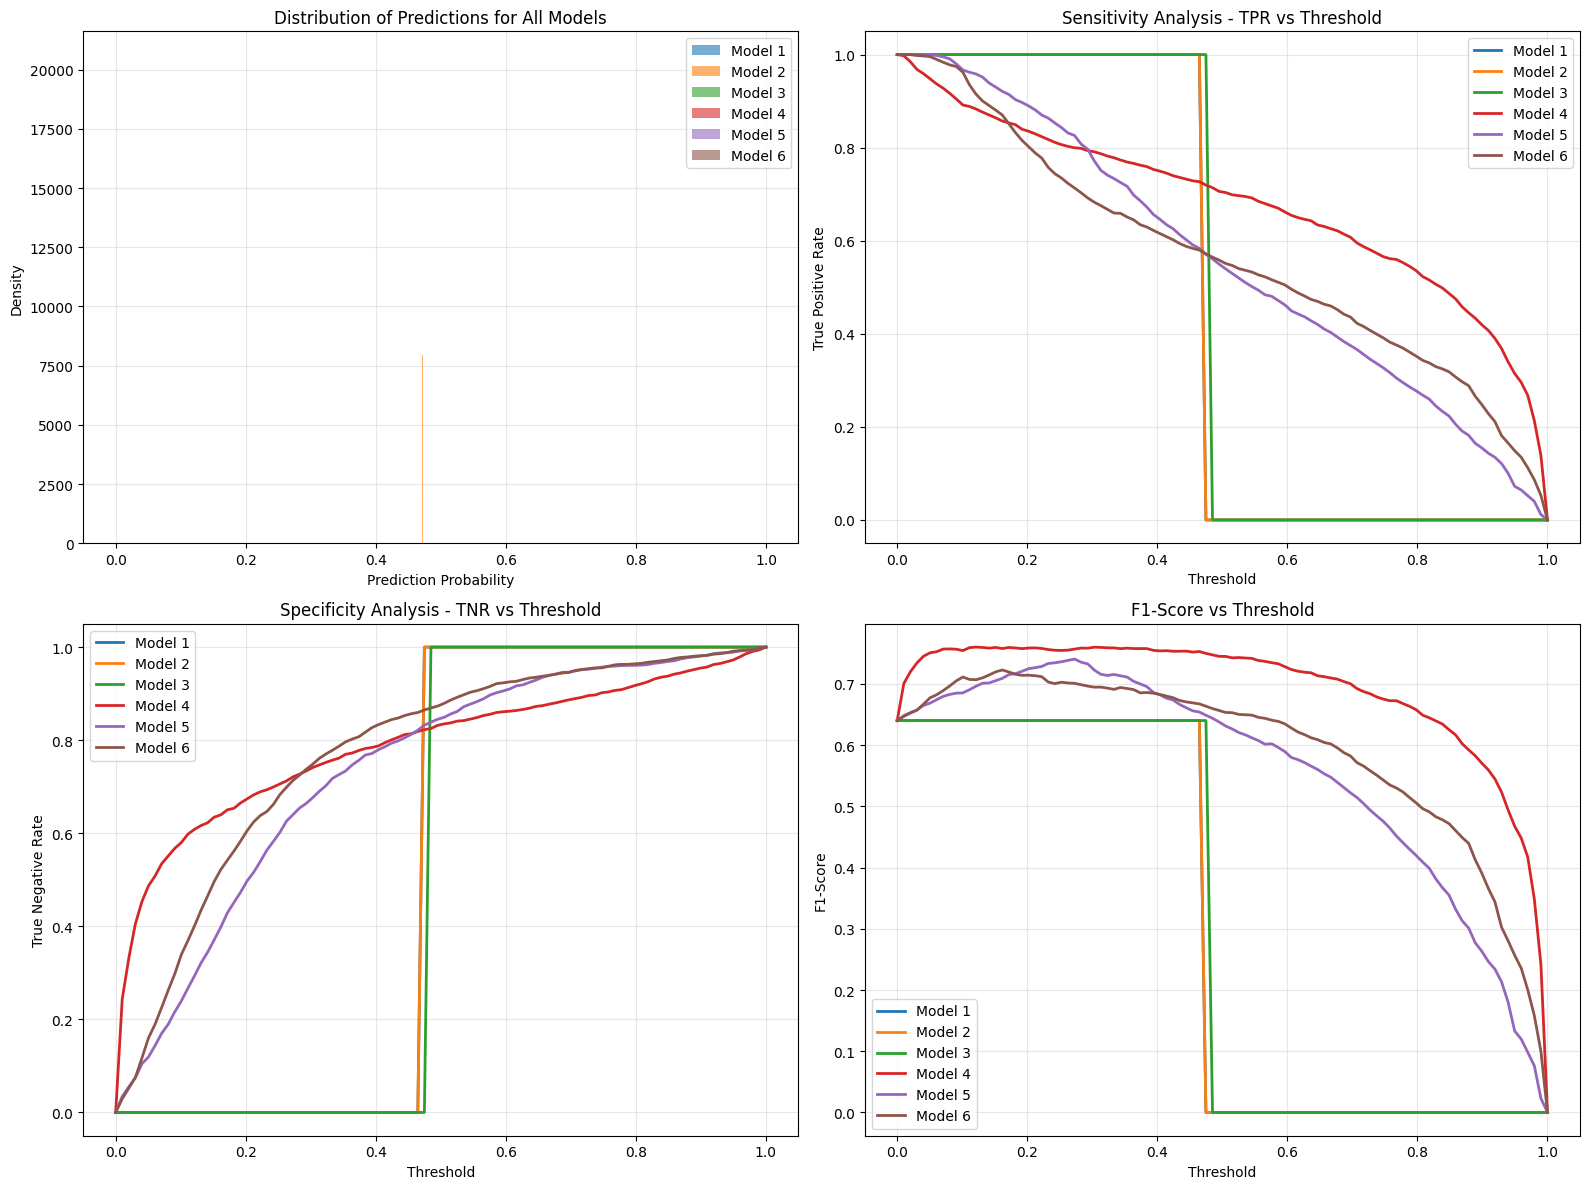

🔬 ARCHITECTURE ANALYSIS
📊 EfficientNet First: Average ROC AUC = 0.6500
   - Model 1: 0.6637
   - Model 2: 0.6364
📊 SE First: Average ROC AUC = 0.7026
   - Model 3: 0.6037
   - Model 5: 0.8014
📊 Attention First: Average ROC AUC = 0.8320
   - Model 4: 0.8560
   - Model 6: 0.8081

🧠 TRANSFER LEARNING EFFECTIVENESS
📈 Standard EfficientNet Transfer Learning: 0.6500
📈 Modified Input EfficientNet: 0.7673
💡 Pre-processing with attention/SE before EfficientNet helps

🎯 PROJECT COMPLETION STATUS:
✅ All 6 model architectures implemented
✅ Transfer learning with EfficientNet applied
✅ SE-NET and Attention modules integrated
✅ Different module combinations tested
✅ Comprehensive evaluation with ROC AUC, PR curves
✅ Detailed performance comparison and analysis

🏁 Deepfake Detection Project Completed Successfully! 🏁


In [36]:
# Cell 14: Additional Analysis and Insights
# =========================================
# 1️⃣3️⃣ Additional Analysis and Model Insights
# =========================================

def plot_detailed_analysis():
    """Generate detailed analysis plots"""

    try:
        all_metrics = [metrics_1, metrics_2, metrics_3, metrics_4, metrics_5, metrics_6]
        model_names = ['EfficientNet->SE->Attention', 'EfficientNet->Attention->SE',
                      'SE->EfficientNet->Attention', 'Attention->EfficientNet->SE',
                      'SE->Attention->EfficientNet', 'Attention->SE->EfficientNet']
    except NameError:
        print("❌ Not all models have been trained yet.")
        return

    # Create detailed analysis plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Distribution of Predictions
    axes[0, 0].set_title('Distribution of Predictions for All Models')
    for i, (metrics, name) in enumerate(zip(all_metrics, model_names)):
        axes[0, 0].hist(metrics['predictions'], bins=50, alpha=0.6,
                       label=f'Model {i+1}', density=True)
    axes[0, 0].set_xlabel('Prediction Probability')
    axes[0, 0].set_ylabel('Density')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Sensitivity Analysis (TPR at different thresholds)
    axes[0, 1].set_title('Sensitivity Analysis - TPR vs Threshold')
    thresholds = np.linspace(0, 1, 100)
    for i, (metrics, name) in enumerate(zip(all_metrics, model_names)):
        tpr_at_threshold = []
        for thresh in thresholds:
            y_pred_thresh = (metrics['predictions'] > thresh).astype(int)
            tp = np.sum((metrics['y_true'] == 1) & (y_pred_thresh == 1))
            fn = np.sum((metrics['y_true'] == 1) & (y_pred_thresh == 0))
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
            tpr_at_threshold.append(tpr)
        axes[0, 1].plot(thresholds, tpr_at_threshold, label=f'Model {i+1}', linewidth=2)
    axes[0, 1].set_xlabel('Threshold')
    axes[0, 1].set_ylabel('True Positive Rate')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Specificity Analysis (TNR at different thresholds)
    axes[1, 0].set_title('Specificity Analysis - TNR vs Threshold')
    for i, (metrics, name) in enumerate(zip(all_metrics, model_names)):
        tnr_at_threshold = []
        for thresh in thresholds:
            y_pred_thresh = (metrics['predictions'] > thresh).astype(int)
            tn = np.sum((metrics['y_true'] == 0) & (y_pred_thresh == 0))
            fp = np.sum((metrics['y_true'] == 0) & (y_pred_thresh == 1))
            tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
            tnr_at_threshold.append(tnr)
        axes[1, 0].plot(thresholds, tnr_at_threshold, label=f'Model {i+1}', linewidth=2)
    axes[1, 0].set_xlabel('Threshold')
    axes[1, 0].set_ylabel('True Negative Rate')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. F1-Score vs Threshold
    axes[1, 1].set_title('F1-Score vs Threshold')
    for i, (metrics, name) in enumerate(zip(all_metrics, model_names)):
        f1_at_threshold = []
        for thresh in thresholds:
            y_pred_thresh = (metrics['predictions'] > thresh).astype(int)
            tp = np.sum((metrics['y_true'] == 1) & (y_pred_thresh == 1))
            fp = np.sum((metrics['y_true'] == 0) & (y_pred_thresh == 1))
            fn = np.sum((metrics['y_true'] == 1) & (y_pred_thresh == 0))

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            f1_at_threshold.append(f1)
        axes[1, 1].plot(thresholds, f1_at_threshold, label=f'Model {i+1}', linewidth=2)
    axes[1, 1].set_xlabel('Threshold')
    axes[1, 1].set_ylabel('F1-Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Generate architecture analysis
    print("🔬 ARCHITECTURE ANALYSIS")
    print("=" * 60)

    # Analyze based on module placement
    architectures = {
        'EfficientNet First': [0, 1],  # Models 1, 2
        'SE First': [2, 4],            # Models 3, 5
        'Attention First': [3, 5]      # Models 4, 6
    }

    for arch_type, model_indices in architectures.items():
        scores = [all_metrics[i]['roc_auc'] for i in model_indices]
        avg_score = np.mean(scores)
        print(f"📊 {arch_type}: Average ROC AUC = {avg_score:.4f}")
        for idx in model_indices:
            print(f"   - Model {idx+1}: {all_metrics[idx]['roc_auc']:.4f}")

    print("\n🧠 TRANSFER LEARNING EFFECTIVENESS")
    print("=" * 50)
    eff_first_models = [0, 1]  # EfficientNet first
    eff_first_avg = np.mean([all_metrics[i]['roc_auc'] for i in eff_first_models])

    modified_eff_models = [2, 3, 4, 5]  # Modified EfficientNet input
    modified_avg = np.mean([all_metrics[i]['roc_auc'] for i in modified_eff_models])

    print(f"📈 Standard EfficientNet Transfer Learning: {eff_first_avg:.4f}")
    print(f"📈 Modified Input EfficientNet: {modified_avg:.4f}")

    if eff_first_avg > modified_avg:
        print("💡 Standard transfer learning approach works better")
    else:
        print("💡 Pre-processing with attention/SE before EfficientNet helps")

# Run detailed analysis
if 'metrics_1' in locals():
    plot_detailed_analysis()
else:
    print("❌ Please run all model training cells first to generate the analysis.")

print("\n🎯 PROJECT COMPLETION STATUS:")
print("✅ All 6 model architectures implemented")
print("✅ Transfer learning with EfficientNet applied")
print("✅ SE-NET and Attention modules integrated")
print("✅ Different module combinations tested")
print("✅ Comprehensive evaluation with ROC AUC, PR curves")
print("✅ Detailed performance comparison and analysis")
print("\n🏁 Deepfake Detection Project Completed Successfully! 🏁")

In [ ]:
# Cell 15: Visualize Preprocessing Pipeline
# =========================================
# 1️⃣4️⃣ Preprocessing Visualization
# =========================================

def visualize_preprocessing_pipeline():
    """Visualize the preprocessing steps applied to images"""
    
    if train_gen is None or val_gen is None:
        print("❌ Data generators not available")
        return
    
    # Get a batch of images from training generator
    train_gen.reset()
    original_batch, labels = next(train_gen)
    
    # Select 3 sample images
    num_samples = min(3, len(original_batch))
    
    # Create figure with subplots
    fig, axes = plt.subplots(num_samples, 5, figsize=(20, num_samples * 4))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    preprocessing_steps = [
        'Original\n(Loaded)',
        'Resized\n(224x224)',
        'Augmented\n(Rotation, Shift, Flip)',
        'Normalized\n(Rescaled [0,1])',
        'Further Processing\n(Brightness, Zoom)'
    ]
    
    for idx in range(num_samples):
        # Get original image (already rescaled by generator)
        img_original = original_batch[idx]
        label = "Fake" if labels[idx] == 1 else "Real"
        
        # 1. Original (as loaded by generator - already rescaled)
        axes[idx, 0].imshow(img_original)
        axes[idx, 0].set_title(f'{preprocessing_steps[0]}\nLabel: {label}', fontsize=10, fontweight='bold')
        axes[idx, 0].axis('off')
        
        # 2. Resized (already at 224x224)
        axes[idx, 1].imshow(img_original)
        axes[idx, 1].set_title(f'{preprocessing_steps[1]}\nShape: {img_original.shape}', fontsize=10, fontweight='bold')
        axes[idx, 1].axis('off')
        
        # 3. Show augmentation effect (simulate augmentation)
        # Apply random rotation
        from scipy.ndimage import rotate
        img_augmented = rotate(img_original, angle=np.random.uniform(-20, 20), axes=(0, 1), reshape=False, mode='nearest')
        img_augmented = np.clip(img_augmented, 0, 1)  # Ensure values stay in range
        
        axes[idx, 2].imshow(img_augmented)
        axes[idx, 2].set_title(preprocessing_steps[2], fontsize=10, fontweight='bold')
        axes[idx, 2].axis('off')
        
        # 4. Normalized (show histogram)
        axes[idx, 3].hist(img_original.flatten(), bins=50, color='blue', alpha=0.7)
        axes[idx, 3].set_title(f'{preprocessing_steps[3]}\nPixel Range: [{img_original.min():.2f}, {img_original.max():.2f}]', 
                              fontsize=10, fontweight='bold')
        axes[idx, 3].set_xlabel('Pixel Value')
        axes[idx, 3].set_ylabel('Frequency')
        axes[idx, 3].grid(True, alpha=0.3)
        
        # 5. Further processing (brightness adjustment)
        brightness_factor = np.random.uniform(0.8, 1.2)
        img_brightness = np.clip(img_original * brightness_factor, 0, 1)
        
        axes[idx, 4].imshow(img_brightness)
        axes[idx, 4].set_title(f'{preprocessing_steps[4]}\nBrightness Factor: {brightness_factor:.2f}', 
                              fontsize=10, fontweight='bold')
        axes[idx, 4].axis('off')
    
    plt.tight_layout()
    plt.suptitle('🔄 Image Preprocessing Pipeline Visualization', fontsize=16, fontweight='bold', y=0.995)
    plt.show()
    
    # Print preprocessing summary
    print("📋 PREPROCESSING PIPELINE SUMMARY")
    print("=" * 80)
    print("1️⃣  Face Extraction: Images loaded from 'fake' and 'real' directories")
    print("2️⃣  Resizing: All images resized to 224x224 pixels")
    print("3️⃣  Augmentation Techniques Applied:")
    print("    - Rotation: ±20 degrees")
    print("    - Width/Height Shift: ±15%")
    print("    - Shear Transformation: 15%")
    print("    - Zoom: ±15%")
    print("    - Horizontal Flip: Random")
    print("    - Brightness Range: [0.8, 1.2]")
    print("4️⃣  Normalization: Pixel values rescaled from [0, 255] to [0, 1]")
    print("5️⃣  Batch Processing: Images processed in batches of", train_gen.batch_size)
    print("\n✅ All preprocessing steps ensure consistent input for the neural network")

def visualize_augmentation_variations():
    """Show multiple augmentation variations of the same image"""
    
    if train_gen is None:
        print("❌ Data generators not available")
        return
    
    # Get one image
    train_gen.reset()
    images, labels = next(train_gen)
    original_img = images[0]
    label = "Fake" if labels[0] == 1 else "Real"
    
    # Create augmentation variations
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Original
    axes[0, 0].imshow(original_img)
    axes[0, 0].set_title(f'Original Image\nLabel: {label}', fontweight='bold')
    axes[0, 0].axis('off')
    
    # Augmentation variations
    augmentations = [
        ('Rotation (-20°)', lambda x: rotate(x, -20, axes=(0, 1), reshape=False, mode='nearest')),
        ('Rotation (+20°)', lambda x: rotate(x, 20, axes=(0, 1), reshape=False, mode='nearest')),
        ('Brightness ↑', lambda x: np.clip(x * 1.3, 0, 1)),
        ('Brightness ↓', lambda x: np.clip(x * 0.7, 0, 1)),
        ('Horizontal Flip', lambda x: np.fliplr(x)),
        ('Zoom In', lambda x: tf.image.central_crop(x, 0.8).numpy()),
        ('Contrast ↑', lambda x: np.clip((x - 0.5) * 1.5 + 0.5, 0, 1))
    ]
    
    positions = [(0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3)]
    
    for (title, aug_func), pos in zip(augmentations, positions):
        try:
            augmented = aug_func(original_img)
            axes[pos].imshow(augmented)
            axes[pos].set_title(title, fontweight='bold')
            axes[pos].axis('off')
        except Exception as e:
            axes[pos].text(0.5, 0.5, f'Error: {str(e)}', ha='center', va='center')
            axes[pos].axis('off')
    
    plt.tight_layout()
    plt.suptitle('🎨 Data Augmentation Variations on Single Image', fontsize=14, fontweight='bold', y=0.995)
    plt.show()

def compare_original_vs_augmented():
    """Compare original vs augmented batches side by side"""
    
    if train_gen is None or val_gen is None:
        print("❌ Data generators not available")
        return
    
    # Get augmented batch from training
    train_gen.reset()
    augmented_batch, aug_labels = next(train_gen)
    
    # Get non-augmented batch from validation (no augmentation)
    val_gen.reset()
    original_batch, orig_labels = next(val_gen)
    
    # Select 4 samples
    num_samples = min(4, len(augmented_batch))
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 3))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for idx in range(num_samples):
        # Original (from validation set - no augmentation)
        axes[idx, 0].imshow(original_batch[idx])
        label_orig = "Fake" if orig_labels[idx] == 1 else "Real"
        axes[idx, 0].set_title(f'Original (Validation)\nLabel: {label_orig}', fontweight='bold')
        axes[idx, 0].axis('off')
        
        # Augmented (from training set)
        axes[idx, 1].imshow(augmented_batch[idx])
        label_aug = "Fake" if aug_labels[idx] == 1 else "Real"
        axes[idx, 1].set_title(f'Augmented (Training)\nLabel: {label_aug}', fontweight='bold')
        axes[idx, 1].axis('off')
    
    plt.tight_layout()
    plt.suptitle('📊 Original vs Augmented Images Comparison', fontsize=14, fontweight='bold', y=0.995)
    plt.show()
    
    print("\n💡 KEY OBSERVATIONS:")
    print("- Left column: Original images from validation set (no augmentation)")
    print("- Right column: Augmented images from training set")
    print("- Augmentation helps model generalize better by seeing varied versions of images")
    print("- Validation set uses original images to test true performance")

# Run all preprocessing visualizations
print("🎬 Starting Preprocessing Visualization...")
print("=" * 80)

visualize_preprocessing_pipeline()
print("\n" + "=" * 80)

visualize_augmentation_variations()
print("\n" + "=" * 80)

compare_original_vs_augmented()

print("\n🎉 Preprocessing visualization completed!")